# Using RNNs (cont.)

This time, we're going to look at something a little less clean than a sine wave.

## FRED Retail Sales Dataset

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
# We can convert dates from spreadsheets into the datetime format
df = pd.read_csv(os.path.join(os.getcwd(), '..', 'DATA', 'RSCCASN.csv'), parse_dates=True, index_col='DATE')

In [3]:
df.head()

,RSCCASN
DATE,
1992-01-01,6938
1992-02-01,7524
1992-03-01,8475
1992-04-01,9401
1992-05-01,9558


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 334 entries, 1992-01-01 to 2019-10-01
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   RSCCASN  334 non-null    int64
dtypes: int64(1)
memory usage: 5.2 KB


Note the datetime index instead of a regular index.

In [5]:
df.columns=['Sales']

<Axes: xlabel='DATE'>

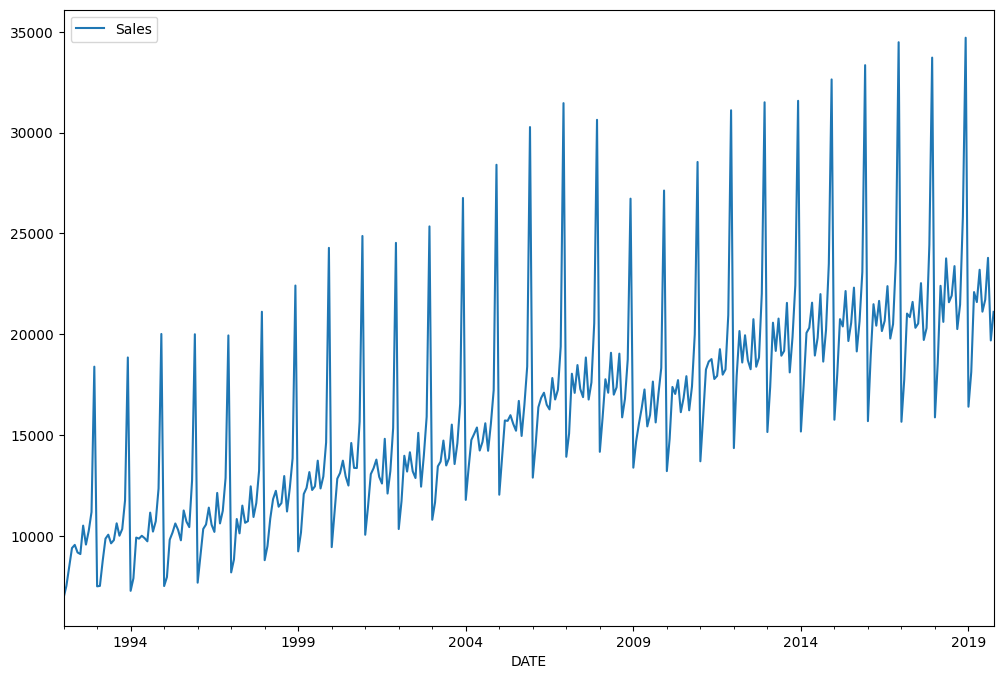

In [6]:
df.plot(figsize=(12,8))

Let's use the last 18 months' worth of data for our train-test split. As we can see above, each data point is one month.

In [7]:
test_point = 24
test_ind = len(df) - test_point
test_ind

310

In [8]:
x = df.iloc[:test_ind]
y = df.iloc[test_point:]

In [9]:
x.shape

(310, 1)

In [10]:
y.shape

(310, 1)

In [11]:
x_train = x[:-test_point]
x_test = x[-test_point:]

y_train = y[:-test_point]
y_test = y[-test_point:]

In [12]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

In [13]:
scaler.fit(x_train)

,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False


In [14]:
scaled_x_train = scaler.transform(x_train).reshape(-1,1)
scaled_y_train = scaler.transform(y_train).reshape(-1,1)

scaled_x_test = scaler.transform(x_test).reshape(-1,1)
scaled_y_test = scaler.transform(y_test).reshape(-1,1)

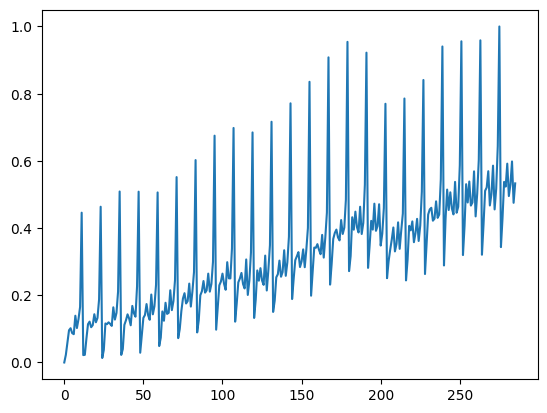

In [15]:
plt.plot(scaled_x_train)

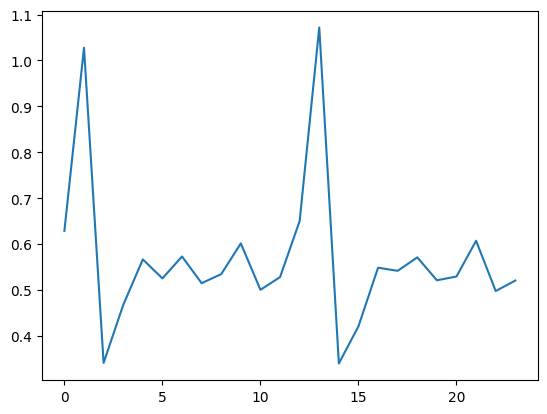

In [16]:
plt.plot(scaled_x_test)

In [17]:
from tensorflow.keras.preprocessing import timeseries_dataset_from_array

C:\Users\Jay\AppData\Roaming\Python\Python313\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [18]:
# l = test_point
# b = int(test_point / 1.5)

# ds = timeseries_dataset_from_array(data=scaled_train[:-l],
#                                    targets=scaled_train[l:],
#                                    sequence_length=l)

In [19]:
# for batch in ds:
#     inputs, targets = batch
#     print(f'Input: {inputs}, Target: {targets}')

In [20]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, LSTM, Dropout

In [21]:
n_features = 1

In [22]:
# Define model.
model = Sequential()

model.add(Input(shape=(scaled_x_train.shape[0], n_features)))
model.add(LSTM(units=32, activation='relu')) # Let's try ReLU this time.
model.add(Dropout(0.2))
model.add(Dense(30, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')

In [23]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 32)                  │           4,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 30)                  │             990 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 30)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              31 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 5,373 (20.99 KB)

 Trainable params: 5,373 (20.99 KB)

 Non-trainable params: 0 (0.00 B)

In [24]:
from tensorflow.keras.callbacks import EarlyStopping
early_stop = EarlyStopping(monitor='val_loss', patience=8)

In [25]:
# l2 = int(l/2)
# val_ds = timeseries_dataset_from_array(data=scaled_test[-l:],
#                                        targets=scaled_test[:l],
#                                        sequence_length=l)

In [26]:
# Let's see how this goes.
model.fit(x=scaled_x_train, y=scaled_y_train, validation_data=(scaled_x_test, scaled_y_test), epochs=60, callbacks=[early_stop])

Epoch 1/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.1467 - val_loss: 0.3058
Epoch 2/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.1124 - val_loss: 0.2393
Epoch 3/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0794 - val_loss: 0.1755
Epoch 4/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0516 - val_loss: 0.1214
Epoch 5/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0378 - val_loss: 0.0800
Epoch 6/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0299 - val_loss: 0.0547
Epoch 7/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0283 - val_loss: 0.0431
Epoch 8/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0273 - val_loss: 0.0404
Epoch 9/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0264 - val_loss: 0.0423
Epoch 10/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0261 - val_loss: 0.0422
Epoch 11/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0229 - val_loss: 0.0405
Epoch 12/60
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0225 - val_loss: 0.0378
Epoch 13/60


<Axes: >

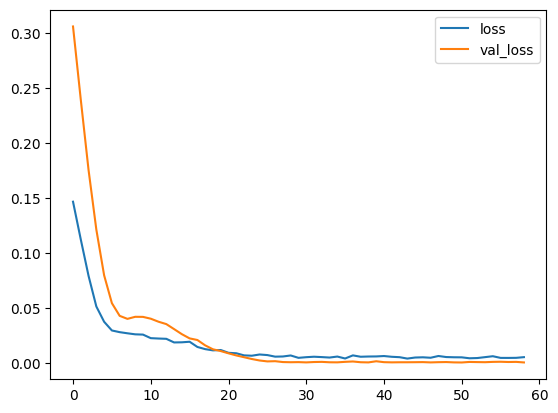

In [27]:
losses = pd.DataFrame(model.history.history)
losses.plot()

In [28]:
# test_preds = []
# curr_batch = scaled_train[-l:]

# for i in range(len(scaled_test)):
#     test_ds = timeseries_dataset_from_array(data=curr_batch,
#                                             targets=None,
#                                             sequence_length=l)
    
#     pred_val = model.predict(test_ds)
#     print(f'Predicted: {pred_val[0][0]:.3f}, Actual: {scaled_test[i][0]:.3f}')
#     curr_batch = np.append(curr_batch[1:], [pred_val]).reshape(-1,1) # Again, we need the 2D shape here
#     test_preds = np.append(test_preds, [pred_val]).reshape(-1,1)

In [29]:
preds = model.predict(scaled_x_test)
#preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step


In [30]:
#scaled_y_test

In [31]:
pred_df = pd.DataFrame({'Actual': scaled_y_test.reshape(-1,), 'Predicted': preds.reshape(-1,)})

<Axes: >

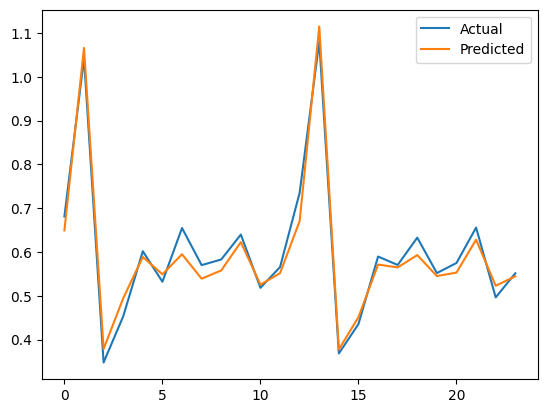

In [32]:
pred_df.plot()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


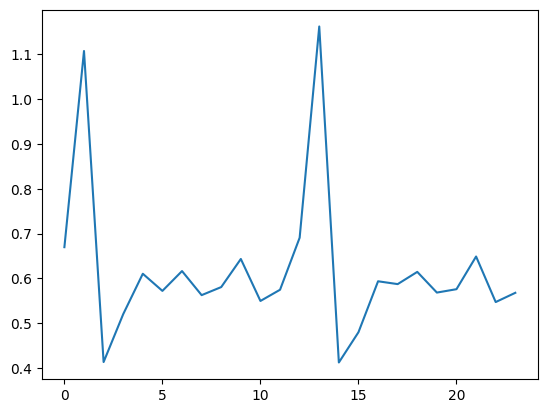

In [33]:
forecast = model.predict(preds)
plt.plot(forecast)

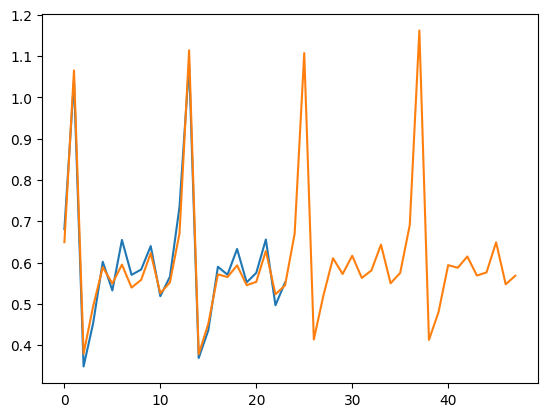

In [34]:
plt.plot(np.arange(len(scaled_x_test)), scaled_y_test, np.arange(2*len(scaled_x_test)), np.append(preds, forecast))

In [35]:
test_preds = []
curr_batch = scaled_x_test
n_periods = 10

for i in range(n_periods):
    pred_val = model.predict(curr_batch)
    curr_batch = pred_val
    test_preds = np.append(test_preds, [pred_val]).reshape(-1,1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


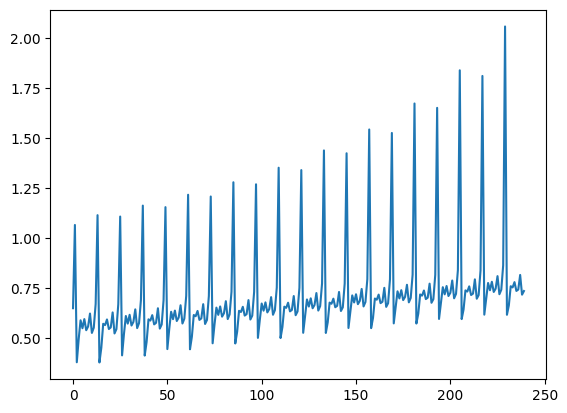

In [36]:
plt.plot(test_preds)

That looks a little wacky but the only real issue is that the rest of the trend isn't rising with the maximum.

Let's unscale this and add it to the original dataframe.

In [37]:
# Remember that the first set of preds is based on the test data, i.e., 2017-19
unscaled_preds = scaler.inverse_transform(test_preds[test_point:])

In [38]:
forecast_index = pd.date_range(start='2019-11-01', periods=(n_periods-1)*test_point, freq='MS')
forecast_index

DatetimeIndex(['2019-11-01', '2019-12-01', '2020-01-01', '2020-02-01',
               '2020-03-01', '2020-04-01', '2020-05-01', '2020-06-01',
               '2020-07-01', '2020-08-01',
               ...
               '2037-01-01', '2037-02-01', '2037-03-01', '2037-04-01',
               '2037-05-01', '2037-06-01', '2037-07-01', '2037-08-01',
               '2037-09-01', '2037-10-01'],
              dtype='datetime64[ns]', length=216, freq='MS')

In [39]:
forecast_df = pd.DataFrame(data=unscaled_preds, index=forecast_index, columns=['Forecast'])

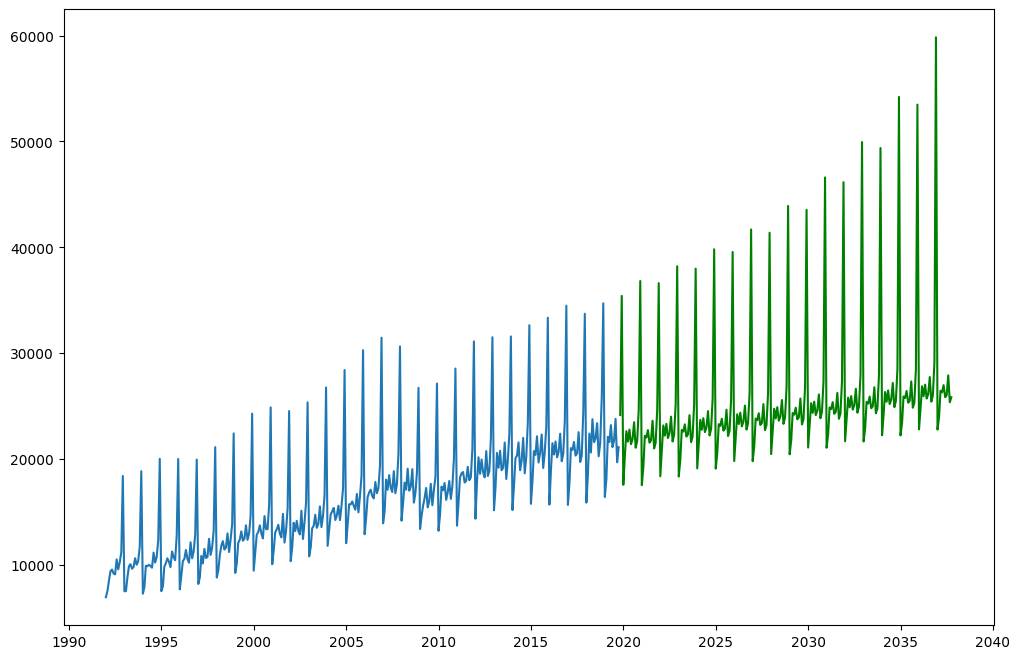

In [40]:
plt.figure(figsize=(12,8))
plt.plot(df)
plt.plot(forecast_df, 'g')

Good thing nothing happened right [after this dataset ends](https://en.wikipedia.org/wiki/COVID-19_pandemic) that would dramatically change the shape of this curve or anything.